# **SMS_SPAM DETECTION USING SUPPORT VECTOR MACHINE**

# **Data Collection**

In [3]:
import pandas as pd

df = pd.read_csv('/content/spam_data.csv', encoding='latin-1')
display(df.head())

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# **Data Preprocessing**

,count
v1,
ham,4825
spam,747


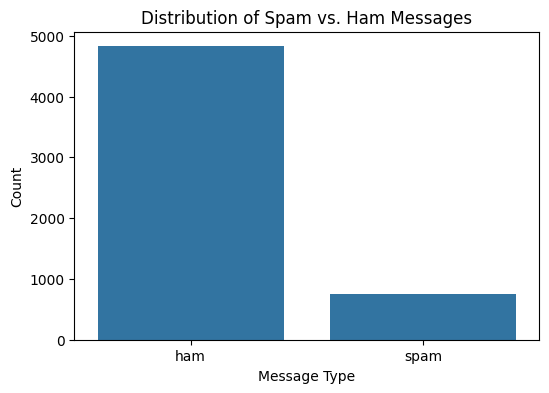

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check class balance
display(df['v1'].value_counts())

# Visualize class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='v1', data=df)
plt.title('Distribution of Spam vs. Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

In [5]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords and lemmatize
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    text = ' '.join(text)
    return text

# Apply the cleaning function to the text column
df['cleaned_text'] = df['v2'].apply(clean_text)

display(df[['v2', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,v2,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


# **Feature Extraction and Selection**

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the cleaned text
X = tfidf_vectorizer.fit_transform(df['cleaned_text'])
y = df['v1']

display(X.shape)

(5572, 5000)

# **Model Training**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train LinearSVC model
model = LinearSVC(random_state=42)
model.fit(X_train, y_train)

display("Model training complete.")

'Model training complete.'

# **Model Evaluation and Visualization**

Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



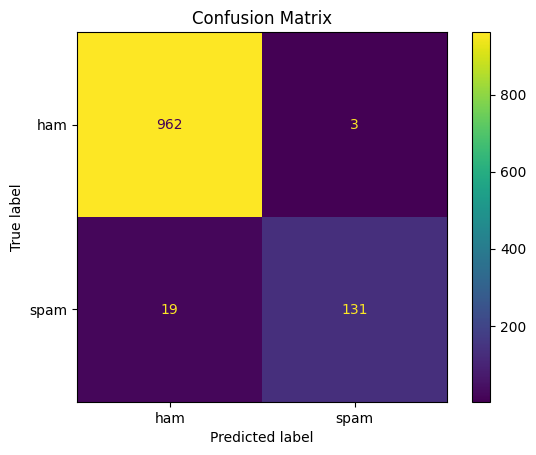

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
y_pred = model.predict(X_test)

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title('Confusion Matrix')
plt.show()

# **Saving Best Model and Vectorizer**

In [9]:
import joblib

# Save the trained model
joblib.dump(model, 'svm_model.pkl')

# Save the TF-IDF vectorizer
joblib.dump(tfidf_vectorizer, 'tfidf_vectorizer.pkl')

display("Model and vectorizer saved successfully.")

'Model and vectorizer saved successfully.'

# **Model Testing on New Text Data**

In [15]:
import joblib
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

# Load the saved model and vectorizer
loaded_model = joblib.load('svm_model.pkl')
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text_for_prediction(text):
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize and remove stopwords and lemmatize
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    text = ' '.join(text)
    return text

# Test with a sample text
sample_text = "Congratulations! You've won a free entry into our weekly competition."
cleaned_sample_text = clean_text_for_prediction(sample_text)

# Transform the cleaned text using the loaded vectorizer
sample_text_features = loaded_vectorizer.transform([cleaned_sample_text])

# Make a prediction
prediction = loaded_model.predict(sample_text_features)

print(f"The sample text is: '{sample_text}'")
print(f"The predicted class is: {prediction[0]}")

The sample text is: 'Congratulations! You've won a free entry into our weekly competition.'
The predicted class is: ham
